In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("height-weight.csv")

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


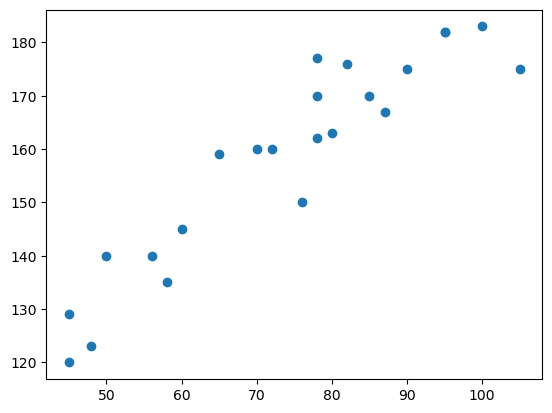

In [6]:
#Plot the data
plt.scatter(df["Weight"],df["Height"])

In [7]:
#Divide the data into dependent and independent features
X=df[["Weight"]]
y=df["Height"]

In [8]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [9]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [10]:
#Split the data into Training data and Testing Data
from sklearn.model_selection import train_test_split
X_Train,X_Test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [11]:
#Standardize the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_Train=scaler.fit_transform(X_Train)
X_Test=scaler.transform(X_Test)

In [12]:
X_Train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [13]:
X_Test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [14]:
#Train the model
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_Train,y_train)

LinearRegression()

In [16]:
#Predict the data 
y_pred=regression.predict(X_Test)

In [ ]:
print("Slope or Coefficient: ",regression.coef_)
print("Intercept: ",regression.intercept_)

Slope or Coefficient:  [17.2982057]
Intercept:  156.47058823529412


In [19]:
#Performance measures
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error: ",mse)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",rmse)

Mean Squared Error:  114.84069295228699
Mean Absolute Error:  9.665125886795005
Root Mean Squared Error:  10.716374991212605


In [20]:
#Model accuracy
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("Model accuracy: ",score*100)

Model accuracy:  73.60826717981276


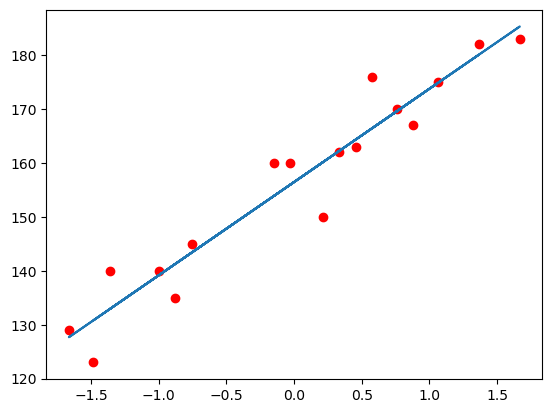

In [22]:
#PLot the best fit line
plt.scatter(X_Train,y_train,color="red")
plt.plot(X_Train,regression.predict(X_Train))

In [25]:
#Predict the height for a given weight
test_weight=scaler.transform(pd.DataFrame([[72]],columns=["Weight"]))
predicted_Ht = regression.predict(test_weight)
print("Predicted Height for weight 72kg: ",predicted_Ht)

Predicted Height for weight 72kg:  [155.97744705]
